# Simulation with shocks and deterministic choice


In [1]:
import sys
sys.path.append("/Users/sofiacattaneo/tesi-inequality/src")
import numpy as np
import matplotlib.pyplot as plt
print(sys.path)

['/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python311.zip', '/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python3.11', '/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python3.11/lib-dynload', '', '/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python3.11/site-packages', '/Users/sofiacattaneo/tesi-inequality/src']


In [2]:
from parameters import *
from functions import *
from conditions import *
from distributions import *
from simulations_shock import *
from dynamics import *

#### Fine tuning dei parametri s.t. a_L senza shock sia sopra la bisettrice in x^F e che a_R sia sempre >1 => n^p_fin= 1

In [ ]:
p = 0.5
q = 0.5
gamma_p = 0.5
gamma_up = 0.8

F=1.5
xF= F/(1+mu)
n_p=0
EAup= EA_up(A_up_bar)

print ('Condizione 35 expected ',Primacondizione(mu, r, alpha, xF, EAup, Ybar))
print ('Condizione 36 expected ',Secondacondizione())
print ('Condizione 37(np=0) expected ',Terzacondizione())
print ('Condizione 47(np=1) expected ',Quartacondizione())
print('')
print ('Condizione 35 no shock ',Primacondizionenoshock())
print ('Condizione 36 no shock ',Secondacondizionenoshock())
print ('Condizione 37(np=0) no shock',Terzacondizionenoshock())
print ('Condizione 47(np=1) no shock ',Quartacondizionenoshock())
print('')
print ('Condizione 35 shock ',Primacondizioneshock())
print ('Condizione 36 shock ',Secondacondizioneshock())
print ('Condizione 37(np=0) shock',Terzacondizioneshock())
print ('Condizione 47(np=1) shock ',Quartacondizioneshock())

Condizione 35 expected  True
Condizione 36 expected  True
Condizione 37(np=0) expected  True
Condizione 47(np=1) expected  True

Condizione 35 no shock  False
Condizione 36 no shock  True
Condizione 37(np=0) no shock False
Condizione 47(np=1) no shock  True

Condizione 35 shock  True
Condizione 36 shock  False
Condizione 37(np=0) shock True
Condizione 47(np=1) shock  True


In [4]:
T=500
yhigh=0.44
y = uniform_initial(N, low=0, high=yhigh)
n_p = np.mean(y > xF)
print('n_p_initial=', n_p)
history = simulate_shock(lambda N: uniform_initial(N, low=0, high=yhigh), update_wealth, T)
n_p= np.mean(history[T]>xF)
meanwealth= np.mean(history[T])

print('mean final wealth =', meanwealth)
print('n_p_final=', n_p)

n_p_initial= 0.0
mean final wealth = 7.551885627557165e+155
n_p_final= 1.0


mean wealth at t= 0 :	 0.21983169571888964
mean wealth at t= 1 :	 0.28959383676737216
mean wealth at t= 100 :	 1.3922304115758386e+30
mean wealth at t= 200 :	 3.365879727285166e+63
mean wealth at t= 350 :	 7.121340016151896e+109
mean wealth at t= 500 :	 7.551885627557165e+155


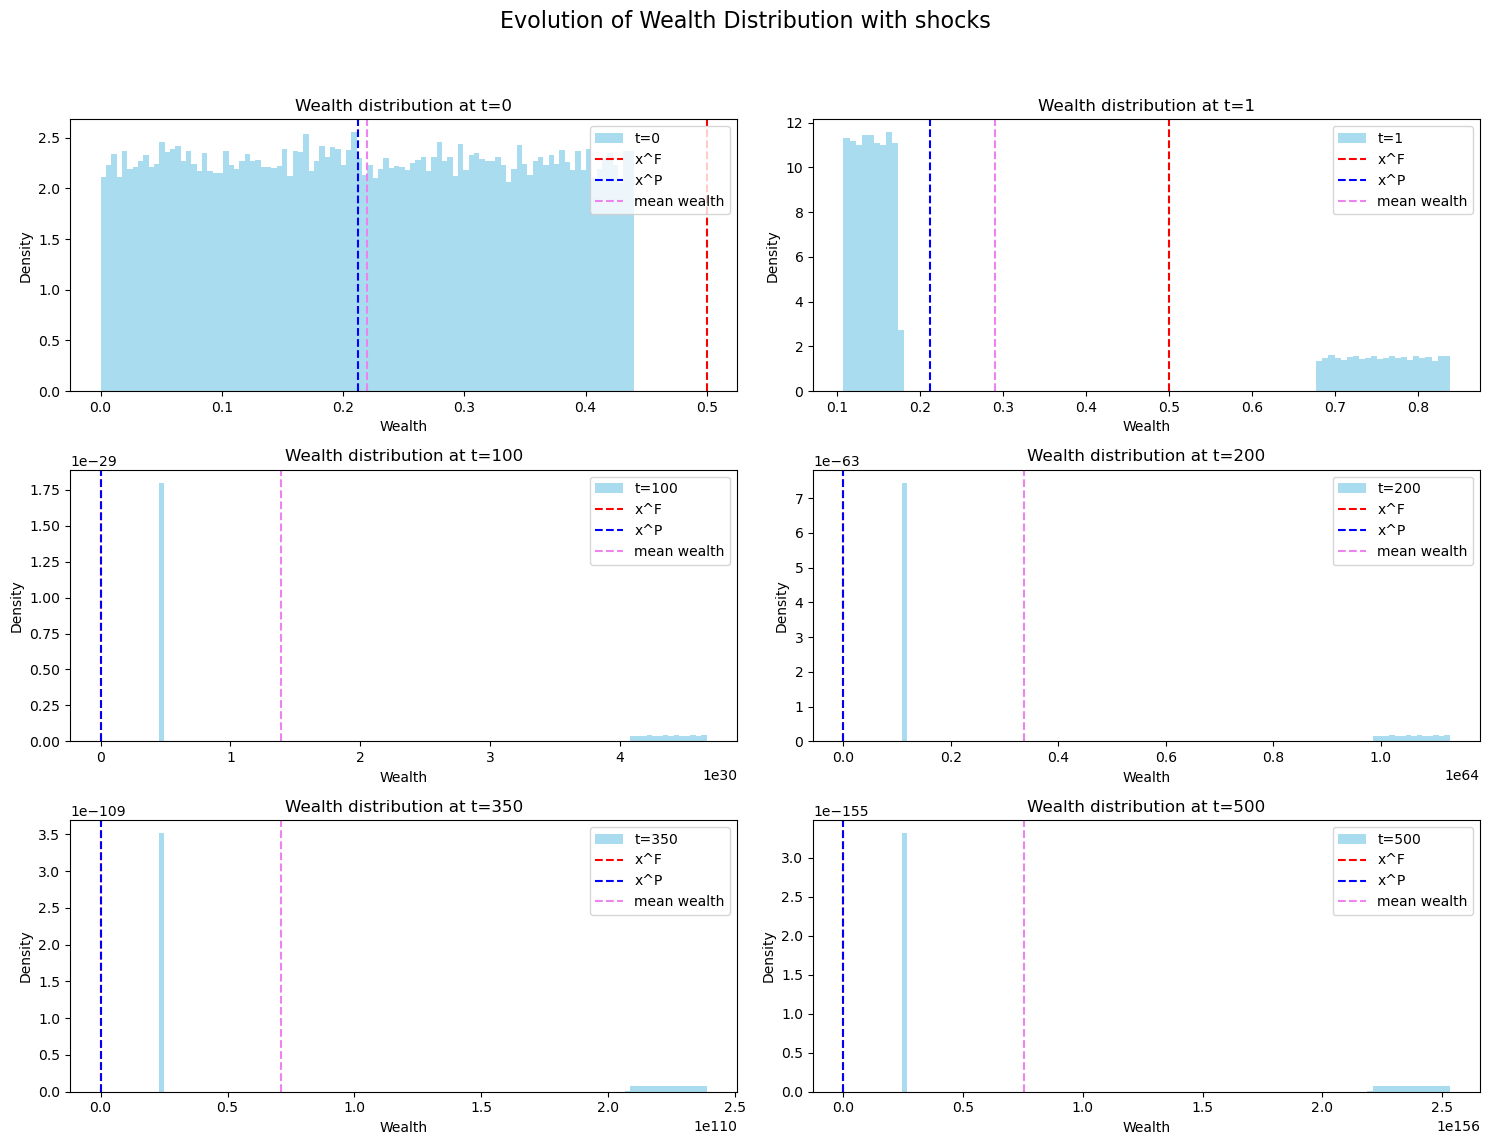

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12)) # Create a 3x2 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, t_val in enumerate([0, 1, 100, 200, 350, 500]):
    t = t_val
    ax = axes[i]
    mean=np.mean(history[t])
    ax.hist(history[t], bins=100, alpha=0.7, label=f"t={t}", density=True, color='skyblue')
    ax.axvline(xF, color='red', linestyle='--', label="x^F")
    ax.axvline(xp(), color='blue', linestyle='--', label="x^P")
    ax.axvline(mean, color='violet', linestyle='--', label="mean wealth")
    ax.legend()
    ax.set_title(f"Wealth distribution at t={t}")
    ax.set_xlabel("Wealth")
    ax.set_ylabel("Density")
    print('mean wealth at t=',t, ':\t', mean)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Evolution of Wealth Distribution with shocks', fontsize=16) # Add a main title to the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle
plt.show()

osserva: xF è una soglia calcolata sui valori medi quindi senza shock non fa davvero da constraint perchè senza shock tutto è sopra la bisettrice. quella divisione di Mosè a t=1 in 0.36 suppongo sia dovuta alla differenza tra le slopes aR e aL.


#### Fine tuning dei parametri s.t. a_L senza shock sia sotto la bisettrice in x^F e che a_R sia sempre >1 => n^p_fin=

In [15]:
p = 0.5
q = 0.5
gamma_p = 0.5
gamma_up = 0.8

F=2
xF= F/(1+mu)
n_p=0

print ('Condizione 35 expected ',Primacondizione())
print ('Condizione 36 expected ',Secondacondizione())
print ('Condizione 37(np=0) expected ',Terzacondizione())
print ('Condizione 47(np=1) expected ',Quartacondizione())
print('')
print ('Condizione 35 no shock ',Primacondizionenoshock())
print ('Condizione 36 no shock ',Secondacondizionenoshock())
print ('Condizione 37(np=0) no shock',Terzacondizionenoshock())
print ('Condizione 47(np=1) no shock ',Quartacondizionenoshock())
print('')
print ('Condizione 35 shock ',Primacondizioneshock())
print ('Condizione 36 shock ',Secondacondizioneshock())
print ('Condizione 37(np=0) shock',Terzacondizioneshock())
print ('Condizione 47(np=1) shock ',Quartacondizioneshock())

Condizione 35 expected  True
Condizione 36 expected  True
Condizione 37(np=0) expected  True
Condizione 47(np=1) expected  True

Condizione 35 no shock  False
Condizione 36 no shock  True
Condizione 37(np=0) no shock False
Condizione 47(np=1) no shock  True

Condizione 35 shock  True
Condizione 36 shock  False
Condizione 37(np=0) shock True
Condizione 47(np=1) shock  True
